
Analyzing: AAPL
Date Range: 2023-11-18 to 2025-11-17
✓ Successfully fetched 500 days of data for AAPL

Dataset Shape: (500, 7)

Column Names:
  - Open
  - High
  - Low
  - Close
  - Volume
  - Dividends
  - Stock Splits

First 5 rows:
                                 Open        High         Low       Close  \
Date                                                                        
2023-11-20 00:00:00-05:00  188.113456  190.114562  188.103555  189.658859   
2023-11-21 00:00:00-05:00  189.619292  189.728263  187.964917  188.856491   
2023-11-22 00:00:00-05:00  189.698511  191.125027  189.044682  189.520187   
2023-11-24 00:00:00-05:00  189.084308  189.114026  187.479469  188.192734   
2023-11-27 00:00:00-05:00  188.143162  188.886146  187.132701  188.014374   

                             Volume  Dividends  Stock Splits  
Date                                                          
2023-11-20 00:00:00-05:00  46505100        0.0           0.0  
2023-11-21 00:00:00-05:00  38134500

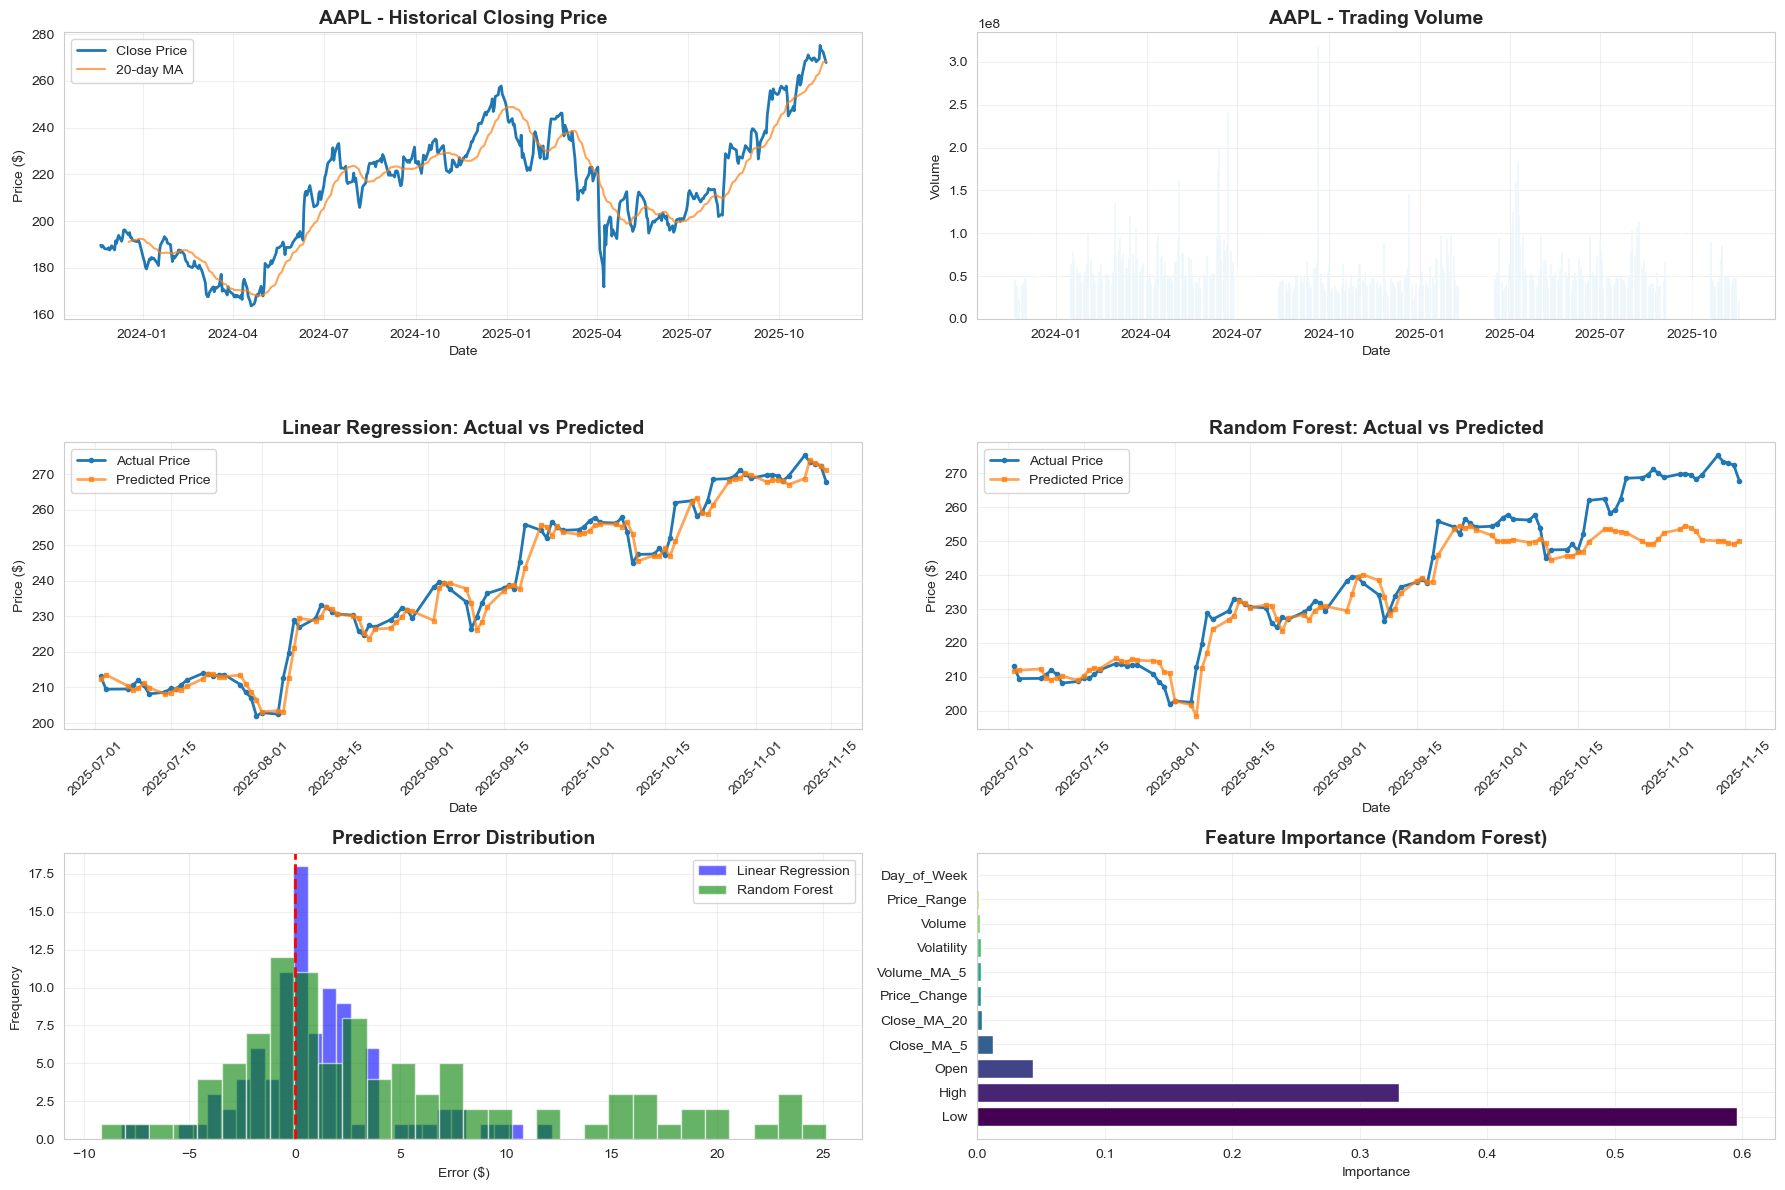

✓ Scatter plot saved as 'AAPL_scatter_comparison.png'


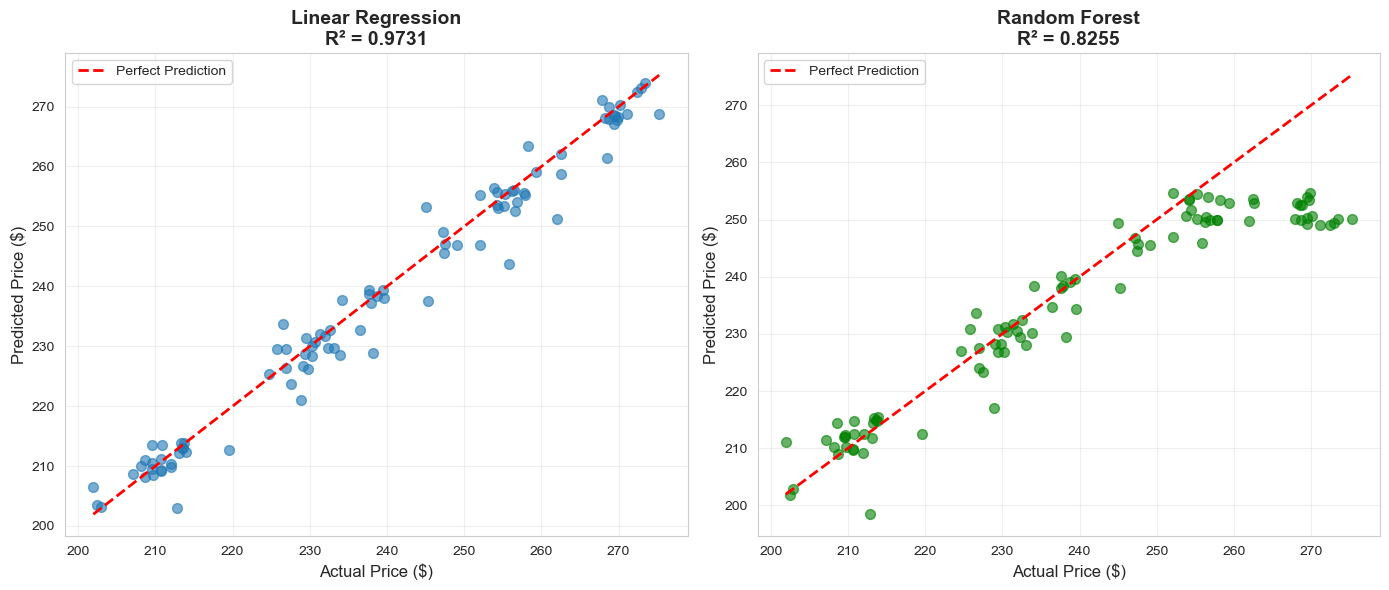


Stock Analyzed: AAPL
Prediction Task: Next day's closing price
Training Period: 384 days
Testing Period: 96 days

Best Model: Linear Regression
  - R² Score: 0.9731
  - RMSE: $3.57
  - Average Error: $2.44

Top 3 Most Important Features:
  3. Low: 0.5961
  2. High: 0.3310
  1. Open: 0.0438

ANALYSIS COMPLETE!

Note: Stock price prediction is inherently uncertain.
These models are for educational purposes only.
Always consult financial advisors for investment decisions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Stock data
import yfinance as yf

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)



# Select stocks to analyze
STOCKS = ['AAPL', 'TSLA', 'GOOGL']  
SELECTED_STOCK = 'AAPL'  

# Date range
END_DATE = datetime.now()
START_DATE = END_DATE - timedelta(days=730)

print(f"\nAnalyzing: {SELECTED_STOCK}")
print(f"Date Range: {START_DATE.strftime('%Y-%m-%d')} to {END_DATE.strftime('%Y-%m-%d')}")


def fetch_stock_data(ticker, start, end):
    
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(start=start, end=end)
        print(f"✓ Successfully fetched {len(df)} days of data for {ticker}")
        return df
    except Exception as e:
        print(f"✗ Error fetching data: {e}")
        return None


stock_data = fetch_stock_data(SELECTED_STOCK, START_DATE, END_DATE)

if stock_data is None or len(stock_data) == 0:
    print("Error: Could not fetch stock data.")
    exit()


print(f"\nDataset Shape: {stock_data.shape}")
print(f"\nColumn Names:")
for col in stock_data.columns:
    print(f"  - {col}")

print(f"\nFirst 5 rows:")
print(stock_data.head())

print(f"\nLast 5 rows:")
print(stock_data.tail())

print(f"\nDataset Info:")
stock_data.info()

print(f"\nDescriptive Statistics:")
print(stock_data.describe())

print(f"\nMissing Values:")
print(stock_data.isnull().sum())


# Create a copy for modeling
df = stock_data.copy()

# Create target variable: Next day's closing price
df['Next_Close'] = df['Close'].shift(-1)

# Create additional features
df['Price_Range'] = df['High'] - df['Low']
df['Price_Change'] = df['Close'] - df['Open']
df['Volume_MA_5'] = df['Volume'].rolling(window=5).mean()
df['Close_MA_5'] = df['Close'].rolling(window=5).mean()
df['Close_MA_20'] = df['Close'].rolling(window=20).mean()
df['Volatility'] = df['Close'].rolling(window=5).std()


df['Day_of_Week'] = df.index.dayofweek


df = df.dropna()

print(f"\nFeatures created:")
print(f"  - Next_Close (Target): Next day's closing price")
print(f"  - Price_Range: High - Low")
print(f"  - Price_Change: Close - Open")
print(f"  - Volume_MA_5: 5-day moving average of volume")
print(f"  - Close_MA_5: 5-day moving average of close price")
print(f"  - Close_MA_20: 20-day moving average of close price")
print(f"  - Volatility: 5-day rolling standard deviation")
print(f"  - Day_of_Week: Day of the week (0-6)")

print(f"\nDataset shape after feature engineering: {df.shape}")



# Select features for prediction
feature_columns = ['Open', 'High', 'Low', 'Volume', 'Price_Range', 
                   'Price_Change', 'Volume_MA_5', 'Close_MA_5', 
                   'Close_MA_20', 'Volatility', 'Day_of_Week']

X = df[feature_columns]
y = df['Next_Close']

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")

# Split data: 80% train, 20% test
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTraining Set: {X_train.shape[0]} samples")
print(f"Testing Set: {X_test.shape[0]} samples")
print(f"Train Period: {df.index[0].strftime('%Y-%m-%d')} to {df.index[split_idx-1].strftime('%Y-%m-%d')}")
print(f"Test Period: {df.index[split_idx].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")


# Model 1: Linear Regression
print("\n1. Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("✓ Linear Regression trained")

# Model 2: Random Forest Regressor
print("\n2. Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, 
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("✓ Random Forest trained")


def evaluate_model(y_true, y_pred, model_name):
    """Calculate and display model metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{model_name} Metrics:")
    print(f"  RMSE (Root Mean Squared Error): ${rmse:.2f}")
    print(f"  MAE (Mean Absolute Error): ${mae:.2f}")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAPE (Mean Absolute % Error): {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

lr_metrics = evaluate_model(y_test, lr_pred, "Linear Regression")
rf_metrics = evaluate_model(y_test, rf_pred, "Random Forest")

# Compare models
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
comparison = pd.DataFrame({
    'Linear Regression': lr_metrics,
    'Random Forest': rf_metrics
})
print("\n", comparison)


feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n", feature_importance)


fig = plt.figure(figsize=(18, 12))

# 1. Stock Price History
plt.subplot(3, 2, 1)
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=2)
plt.plot(stock_data.index, stock_data['Close'].rolling(20).mean(), 
         label='20-day MA', alpha=0.7, linewidth=1.5)
plt.title(f'{SELECTED_STOCK} - Historical Closing Price', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(3, 2, 2)
plt.bar(stock_data.index, stock_data['Volume'], alpha=0.6, color='skyblue')
plt.title(f'{SELECTED_STOCK} - Trading Volume', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)

# 3. Actual vs Predicted - Linear Regression
plt.subplot(3, 2, 3)
test_dates = df.index[split_idx:]
plt.plot(test_dates, y_test.values, label='Actual Price', 
         linewidth=2, marker='o', markersize=3)
plt.plot(test_dates, lr_pred, label='Predicted Price', 
         linewidth=2, marker='s', markersize=3, alpha=0.7)
plt.title('Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# 4. Actual vs Predicted - Random Forest
plt.subplot(3, 2, 4)
plt.plot(test_dates, y_test.values, label='Actual Price', 
         linewidth=2, marker='o', markersize=3)
plt.plot(test_dates, rf_pred, label='Predicted Price', 
         linewidth=2, marker='s', markersize=3, alpha=0.7)
plt.title('Random Forest: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# 5. Prediction Error Distribution
plt.subplot(3, 2, 5)
lr_errors = y_test.values - lr_pred
rf_errors = y_test.values - rf_pred
plt.hist(lr_errors, bins=30, alpha=0.6, label='Linear Regression', color='blue')
plt.hist(rf_errors, bins=30, alpha=0.6, label='Random Forest', color='green')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Prediction Error Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Error ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Feature Importance
plt.subplot(3, 2, 6)
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SELECTED_STOCK}_prediction_analysis.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Visualization saved as '{SELECTED_STOCK}_prediction_analysis.png'")
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, lr_pred, alpha=0.6, s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'Linear Regression\nR² = {lr_metrics["R2"]:.4f}', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, rf_pred, alpha=0.6, s=50, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)', fontsize=12)
axes[1].set_ylabel('Predicted Price ($)', fontsize=12)
axes[1].set_title(f'Random Forest\nR² = {rf_metrics["R2"]:.4f}', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SELECTED_STOCK}_scatter_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ Scatter plot saved as '{SELECTED_STOCK}_scatter_comparison.png'")
plt.show()



print(f"\nStock Analyzed: {SELECTED_STOCK}")
print(f"Prediction Task: Next day's closing price")
print(f"Training Period: {split_idx} days")
print(f"Testing Period: {len(y_test)} days")

print("\nBest Model: ", end="")
if rf_metrics['R2'] > lr_metrics['R2']:
    print("Random Forest")
    print(f"  - R² Score: {rf_metrics['R2']:.4f}")
    print(f"  - RMSE: ${rf_metrics['RMSE']:.2f}")
    print(f"  - Average Error: ${rf_metrics['MAE']:.2f}")
else:
    print("Linear Regression")
    print(f"  - R² Score: {lr_metrics['R2']:.4f}")
    print(f"  - RMSE: ${lr_metrics['RMSE']:.2f}")
    print(f"  - Average Error: ${lr_metrics['MAE']:.2f}")

print("\nTop 3 Most Important Features:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE!")
print("=" * 70)
print("\nNote: Stock price prediction is inherently uncertain.")
print("These models are for educational purposes only.")
print("Always consult financial advisors for investment decisions.")